<a href="https://colab.research.google.com/github/Kirkumee/study/blob/main/%D0%9E%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5%20%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D1%81%D0%B5%D1%82%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install spectral

import gc
gc.collect()
import warnings
warnings.filterwarnings('ignore')
import time
import numpy as np
from operator import truediv
import scipy.io as sio
import os
import pandas as pd
import seaborn as sns
import spectral
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score
from sklearn.decomposition import IncrementalPCA

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dropout, Input, Conv3D, Flatten, Dense
from keras.models import Model
from keras.optimizers import Adam

In [6]:
from google.colab import files
print("Загрузите PaviaU.mat")
files.upload()
print("Загрузите PaviaU_gt.mat")
files.upload()

Загрузите PaviaU.mat


Saving PaviaU.mat to PaviaU (1).mat
Загрузите PaviaU_gt.mat


Saving PaviaU_gt.mat to PaviaU_gt (1).mat


{'PaviaU_gt (1).mat': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Fri May 20 18:25:52 2011                                                \x00\x01IM\x0f\x00\x00\x00u*\x00\x00x\x9c\xe4\x98\xcfN\x840\x10\xc6\xa7\x0b\x1a\xb8\xf8\x1c\xc6\xe7\xd1\xb3\xd9\xbd\xa87\x0f\xc6\xe7\x17W\x14:\xff\x07h!q\x92\xcd.t\x98~\xed\xf7K\xdb\xe5\x0e\x00^\x1f\x1a\xb8\x1d\xbe\xbb\xe1\xd3\xc3O\xdc\x8c\xd7\x97\x13\xc0c\x02Hc\xdb\xfb\xf9\xf3\xed\xfc\xf4\xfc\xf21\xe6\r\xcdp?<\xbfM\xa4\x94\xf2\x1b\'.\xec:(/e\xb1\x91\xd6\x95\xd1\xfc\xc6Ad\xf0Z\xe8\x84;\x1d\x80\xd9\xac\x0b\xed\xac\xb7r\x84\x87&\x89\xf2\xa8\xb0\xca\xe0\xb4t@\xc4\x14[K\xf5\xa8\xcb\xe0\xd5\xe0)\x8f\xb8\xcdLx\xcb\x94\xaeI\x98\x130\xab3\x92\x96pl\xa2ve\xd4FL\xe8\x88 \xc63\xc6_\x19\x81\xe7\xbbmw&\x8cx\xbf\xb07\x0308\x08e\xea\xf6T\xac;U\x86\xb6\x8c\x91\xdf\x8e@\x88e\x80E\x11\x8b\x8dV\xd4\xc3*\xa0\x92\xd42$\xe7Z6\x1f\xeb?dL\xee\xc9\xcfX\xdchu\xdb\xa8M\x98\xb4G2\x82\xd4:8\x87\xc7\xea\x10\x8cM~\xd6cLn\xb1Oc\x0b|&\x88\xcd\xb7\xca\x9d\t#\x95C\x80\xfd%a\

In [7]:
def SplitTr_Te(HSI, GT, TeRatio, randomState=345):
    Tr, Te, TrC, TeC = train_test_split(
        HSI, GT, test_size=TeRatio, random_state=randomState, stratify=GT)
    return Tr, Te, TrC, TeC

def DL_Method(HSI, numComponents=20):
    RHSI = np.reshape(HSI, (-1, HSI.shape[2]))
    n_batches = 256
    inc_pca = IncrementalPCA(n_components=numComponents)
    for X_batch in np.array_split(RHSI, n_batches):
        inc_pca.partial_fit(X_batch)
    X_ipca = inc_pca.transform(RHSI)
    RHSI = np.reshape(X_ipca, (HSI.shape[0], HSI.shape[1], numComponents))
    return RHSI

def ZeroPad(HSI, margin=2):
    NHSI = np.zeros((HSI.shape[0] + 2*margin,
                     HSI.shape[1] + 2*margin,
                     HSI.shape[2]))
    NHSI[margin:HSI.shape[0]+margin, margin:HSI.shape[1]+margin, :] = HSI
    return NHSI

def HSICubes(HSI, GT, WinSize=11, removeZeroLabels=True):
    margin = int((WinSize - 1) / 2)
    zeroPaddedX = ZeroPad(HSI, margin=margin)
    patchesData   = np.zeros((HSI.shape[0] * HSI.shape[1], WinSize, WinSize, HSI.shape[2]))
    patchesLabels = np.zeros((HSI.shape[0] * HSI.shape[1]))
    patchIndex = 0
    for r in range(margin, zeroPaddedX.shape[0] - margin):
        for c in range(margin, zeroPaddedX.shape[1] - margin):
            patch = zeroPaddedX[r-margin:r+margin+1, c-margin:c+margin+1]
            patchesData[patchIndex, :, :, :] = patch
            patchesLabels[patchIndex] = GT[r-margin, c-margin]
            patchIndex += 1
    if removeZeroLabels:
        patchesData   = patchesData[patchesLabels > 0, :, :, :]
        patchesLabels = patchesLabels[patchesLabels > 0]
        patchesLabels -= 1
    return patchesData, patchesLabels

def AA_andEachClassAccuracy(confusion_matrix):
    list_diag    = np.diag(confusion_matrix)
    list_raw_sum = np.sum(confusion_matrix, axis=1)
    each_acc     = np.nan_to_num(truediv(list_diag, list_raw_sum))
    average_acc  = np.mean(each_acc)
    return each_acc, average_acc

def reports(Te, TeC):
    start  = time.time()
    Y_pred = model.predict(Te)
    y_pred = np.argmax(Y_pred, axis=1)
    end    = time.time()
    total  = end - start

    target_names = ['Asphalt', 'Meadows', 'Gravel', 'Trees',
                    'Painted metal sheets', 'Bare Soil', 'Bitumen',
                    'Self-Blocking Bricks', 'Shadows']

    classification = classification_report(np.argmax(TeC, axis=1), y_pred, target_names=target_names)
    oa        = accuracy_score(np.argmax(TeC, axis=1), y_pred)
    confusion = confusion_matrix(np.argmax(TeC, axis=1), y_pred)
    each_acc, aa = AA_andEachClassAccuracy(confusion)
    kappa     = cohen_kappa_score(np.argmax(TeC, axis=1), y_pred)
    score     = model.evaluate(Te, TeC, batch_size=32, verbose=0)
    Test_Loss     = score[0] * 100
    Test_accuracy = score[1] * 100
    return classification, confusion, Test_Loss, Test_accuracy, oa*100, each_acc*100, aa*100, kappa*100, target_names, y_pred, total

def Patch(data, height_index, width_index):
    height_slice = slice(height_index, height_index + PATCH_SIZE)
    width_slice  = slice(width_index,  width_index  + PATCH_SIZE)
    return data[height_slice, width_slice, :]

In [8]:
HSI = sio.loadmat('PaviaU.mat')['paviaU']
GT  = sio.loadmat('PaviaU_gt.mat')['paviaU_gt']
print("HSI:", HSI.shape)  # (610, 340, 103)
print("GT: ", GT.shape)   # (610, 340)

# iPCA -> 20 компонент
HSI = DL_Method(HSI, numComponents=20)
print("После PCA:", HSI.shape)

# Патчи 11x11x20
HSI, GT = HSICubes(HSI, GT, WinSize=11)
print("Патчи:", HSI.shape)

# Train/Test 70/30
Tr, Te, TrC, TeC = SplitTr_Te(HSI, GT, 0.30)

# Train/Val 70/30
Tr, Tv, TrC, TvC = SplitTr_Te(Tr, TrC, 0.30)
print("Train:", Tr.shape, "Val:", Tv.shape, "Test:", Te.shape)

# Reshape для модели
Tr  = Tr.reshape(-1, 11, 11, 20, 1).astype('float32')
Tv  = Tv.reshape(-1, 11, 11, 20, 1).astype('float32')
Te  = Te.reshape(-1, 11, 11, 20, 1).astype('float32')

num_classes = 9
TrC = tf.keras.utils.to_categorical(TrC, num_classes)
TvC = tf.keras.utils.to_categorical(TvC, num_classes)
TeC = tf.keras.utils.to_categorical(TeC, num_classes)

HSI: (610, 340, 103)
GT:  (610, 340)
После PCA: (610, 340, 20)
Патчи: (42776, 11, 11, 20)
Train: (20960, 11, 11, 20) Val: (8983, 11, 11, 20) Test: (12833, 11, 11, 20)


In [9]:
input_layer = Input((11, 11, 20, 1))
conv_layer1 = Conv3D(filters=8,  kernel_size=(3, 3, 7), activation='relu')(input_layer)
conv_layer2 = Conv3D(filters=16, kernel_size=(3, 3, 5), activation='relu')(conv_layer1)
conv_layer3 = Conv3D(filters=32, kernel_size=(3, 3, 3), activation='relu')(conv_layer2)
conv_layer4 = Conv3D(filters=64, kernel_size=(3, 3, 3), activation='relu')(conv_layer3)
flatten_layer = Flatten()(conv_layer4)
dense_layer1  = Dense(units=256, activation='relu')(flatten_layer)
dense_layer1  = Dropout(0.4)(dense_layer1)
dense_layer2  = Dense(units=128, activation='relu')(dense_layer1)
dense_layer2  = Dropout(0.4)(dense_layer2)
output_layer  = Dense(units=num_classes, activation='softmax')(dense_layer2)

model = Model(inputs=input_layer, outputs=output_layer)
model.summary()

adam = Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 11, 11, 20, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 9, 9, 14, 8)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 7, 7, 10, 16)   │         5,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 5, 5, 8, 32)    │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 3, 3, 6, 64)    │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3456)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 994,553 (3.79 MB)

 Trainable params: 994,553 (3.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.6981 - loss: 2.4381 - val_accuracy: 0.9417 - val_loss: 0.1654
Epoch 2/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9421 - loss: 0.1786 - val_accuracy: 0.9855 - val_loss: 0.0449
Epoch 3/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9751 - loss: 0.0845 - val_accuracy: 0.9925 - val_loss: 0.0212
Epoch 4/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9869 - loss: 0.0461 - val_accuracy: 0.9957 - val_loss: 0.0132
Epoch 5/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.9887 - loss: 0.0383 - val_accuracy: 0.9974 - val_loss: 0.0099
Epoch 6/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9967 - loss: 0.0120 - val_accuracy: 0.9987 - val_loss: 0.0040
Epoch 7/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9911 - loss: 0.0334 - val_accuracy: 0.9935 - val_loss: 0.0221
Epoch 8/50
82/82 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.9961 - loss: 0.0160 - val_accuracy: 0.9991 - v

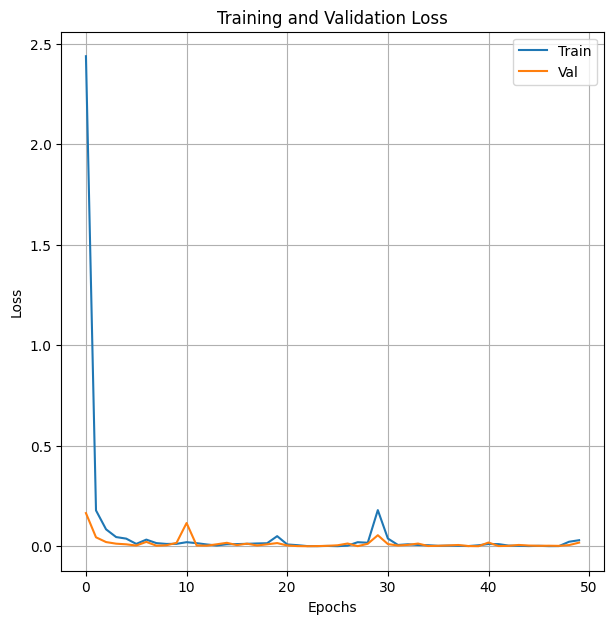

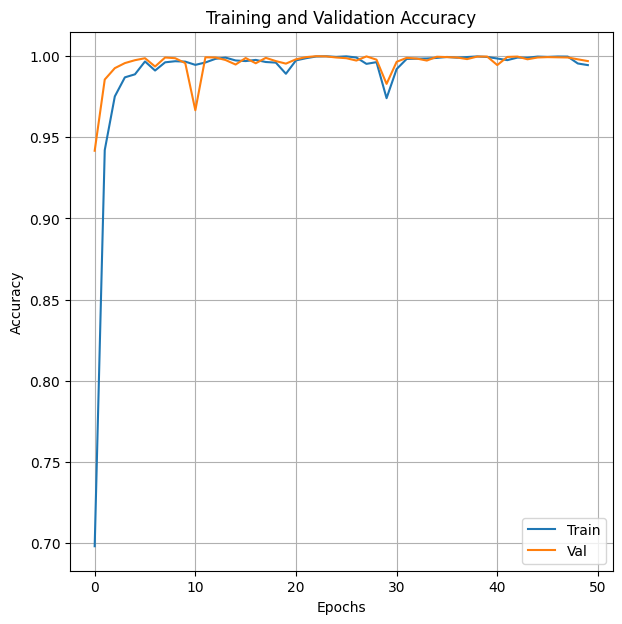

In [10]:
start = time.time()
history = model.fit(x=Tr, y=TrC, batch_size=256, epochs=50, validation_data=(Tv, TvC))
end = time.time()
Tr_Time = end - start
print(f"Время обучения: {Tr_Time:.1f} сек")

plt.figure(figsize=(7,7))
plt.grid()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('Loss'); plt.xlabel('Epochs')
plt.title('Training and Validation Loss')
plt.legend(['Train', 'Val'])
plt.show()

plt.figure(figsize=(7,7))
plt.grid()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylabel('Accuracy'); plt.xlabel('Epochs')
plt.title('Training and Validation Accuracy')
plt.legend(['Train', 'Val'])
plt.show()

from google.colab import drive
drive.mount('/content/drive')
model.save('/content/drive/MyDrive/pavia_model.h5')
print("Модель сохранена на Drive!")

402/402 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step
                      precision    recall  f1-score   support

             Asphalt       1.00      1.00      1.00      1989
             Meadows       1.00      1.00      1.00      5595
              Gravel       1.00      0.99      0.99       630
               Trees       1.00      1.00      1.00       919
Painted metal sheets       1.00      1.00      1.00       403
           Bare Soil       1.00      0.98      0.99      1509
             Bitumen       0.98      1.00      0.99       399
Self-Blocking Bricks       0.99      0.99      0.99      1105
             Shadows       1.00      1.00      1.00       284

            accuracy                           1.00     12833
           macro avg       0.99      0.99      0.99     12833
        weighted avg       1.00      1.00      1.00     12833

OA:    99.58%
AA:    99.47%
Kappa: 99.44%
Train time: 6437.6s | Test time: 41.7s


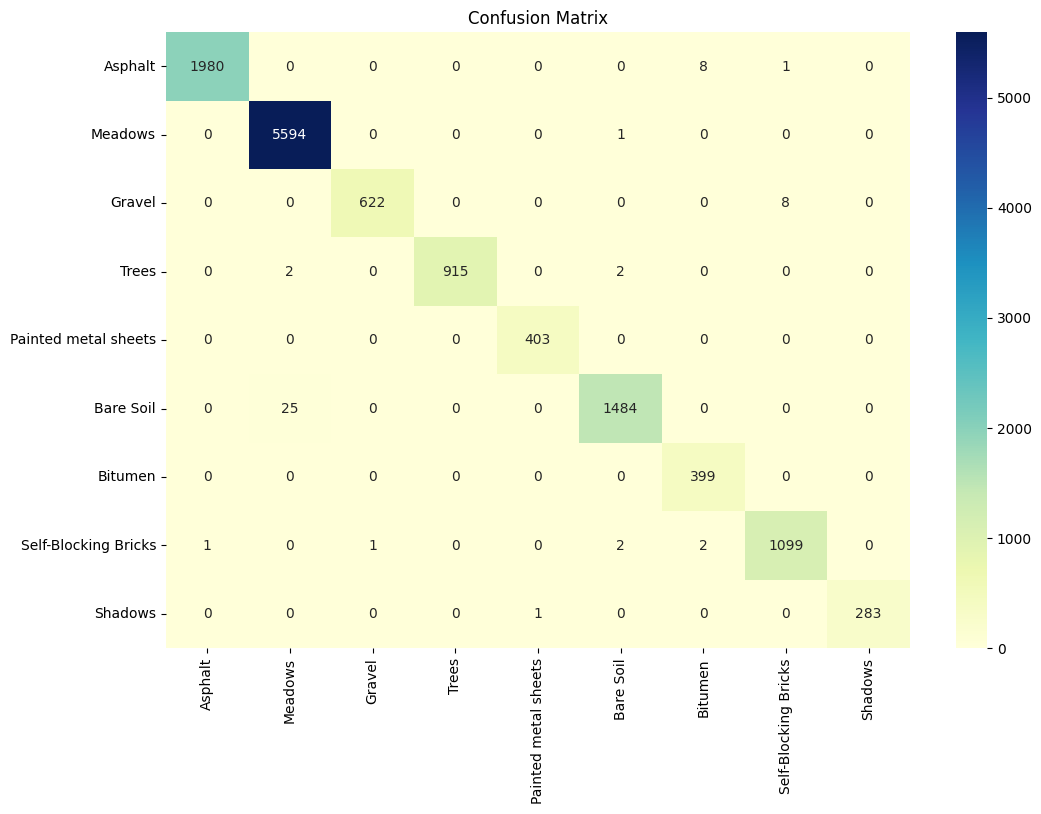

In [11]:
classification, confusion, Test_loss, Test_accuracy, oa, each_acc, aa, kappa, target_names, y_pred, Time = reports(Te, TeC)

print(classification)
print(f"OA:    {oa:.2f}%")
print(f"AA:    {aa:.2f}%")
print(f"Kappa: {kappa:.2f}%")
print(f"Train time: {Tr_Time:.1f}s | Test time: {Time:.1f}s")

# Матрица ошибок
cm_df = pd.DataFrame(confusion, index=target_names, columns=target_names)
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(cm_df, cmap="YlGnBu", annot=True, fmt='d', ax=ax)
plt.title('Confusion Matrix')
plt.show()

Всего патчей: 42776
42/42 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step


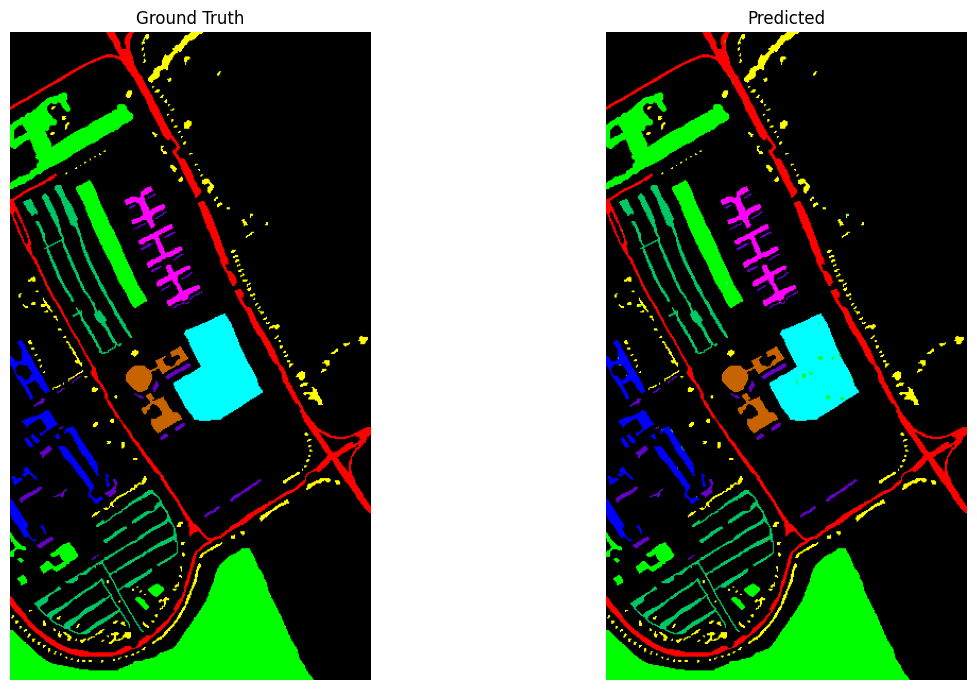

In [13]:
HSI_orig = sio.loadmat('PaviaU.mat')['paviaU']
GT_orig  = sio.loadmat('PaviaU_gt.mat')['paviaU_gt']

height, width = GT_orig.shape
PATCH_SIZE = 11

HSI_map = DL_Method(HSI_orig, numComponents=20)
HSI_map = ZeroPad(HSI_map, PATCH_SIZE // 2)

patches = []
positions = []
for i in range(height):
    for j in range(width):
        if int(GT_orig[i, j]) == 0:
            continue
        patch = Patch(HSI_map, i, j)
        patches.append(patch)
        positions.append((i, j))

patches = np.array(patches).reshape(-1, 11, 11, 20, 1).astype('float32')
print(f"Всего патчей: {len(patches)}")

predictions = model.predict(patches, batch_size=1024, verbose=1)
pred_labels = np.argmax(predictions, axis=1) + 1

outputs = np.zeros((height, width))
for idx, (i, j) in enumerate(positions):
    outputs[i][j] = pred_labels[idx]

spectral.save_rgb("PU_predictions.png", outputs.astype(int), colors=spectral.spy_colors)
spectral.save_rgb("PU_ground_truth.png", GT_orig, colors=spectral.spy_colors)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(plt.imread("PU_ground_truth.png"))
axes[0].set_title("Ground Truth")
axes[0].axis('off')
axes[1].imshow(plt.imread("PU_predictions.png"))
axes[1].set_title("Predicted")
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [14]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

model.save('/content/drive/MyDrive/pavia_model.h5')

shutil.copy('PU_predictions.png', '/content/drive/MyDrive/PU_predictions.png')
shutil.copy('PU_ground_truth.png', '/content/drive/MyDrive/PU_ground_truth.png')

print("Всё сохранено на Google Drive!")

Mounted at /content/drive
Всё сохранено на Google Drive!
